# Preparation for Lab 2 from Group 1 (Wörner, Velez, Northe)

The source code and the binaries from this report can be found in our Github [repository](https://github.com/NortheLo/Microwave_Eng_Lab/tree/main/Lab1_Network_Analysis).

In [17]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

## Task 1: AM-Signal

In [18]:
f_c = 2e9       # [Hz]
f_m = 1e6       # [Hz]

f_s = 100e9
t_max = 3e-6
t = np.arange(0, t_max, 1/f_s)
m = 2.1 * np.cos(2 * np.pi * f_m * t) + 3

In [19]:
s_c = np.cos(2 * np.pi * f_c * t)
s_bp = np.multiply(m, s_c)

### Show both the modulating signal and the modulated signal in your time domain plot.

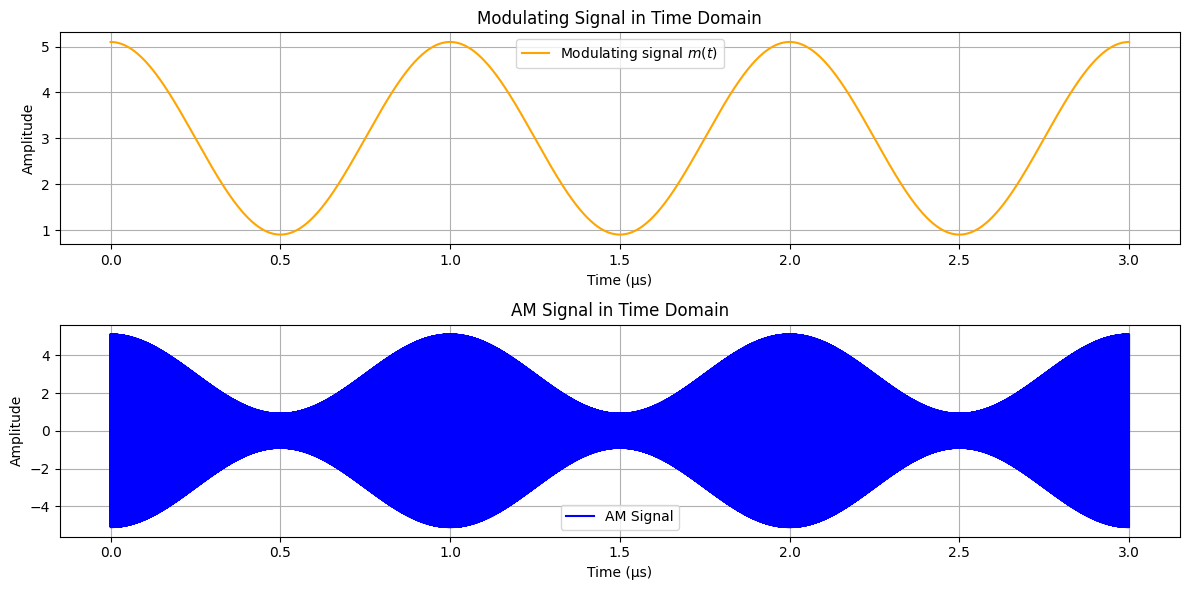

In [20]:

# --- Time domain plots ---
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t * 1e6, m, label="Modulating signal $m(t)$", color='orange')
plt.xlabel("Time (μs)")
plt.ylabel("Amplitude")
plt.title("Modulating Signal in Time Domain")
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t * 1e6, s_bp, label="AM Signal", color='blue')
plt.xlabel("Time (μs)")
plt.ylabel("Amplitude")
plt.title("AM Signal in Time Domain")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Indicate the frequencies and amplitude of the carrier and sidelobes on your spectrum plot.

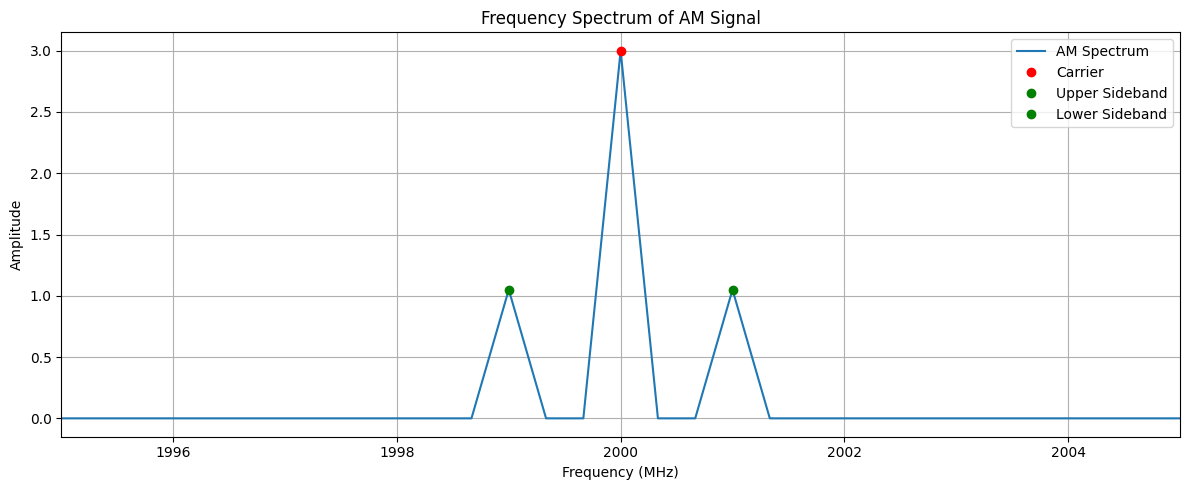

In [21]:
# --- FFT ---
N = len(t)
S = fft(s_bp)
f = fftfreq(N, 1/f_s)

# Keep only positive frequencies
f_pos = f[f > 0]
S_pos = 2 / N * np.abs(S[f > 0])  # Normalize amplitude

# --- Plot frequency spectrum ---
plt.figure(figsize=(12, 5))
plt.plot(f_pos / 1e6, S_pos, label="AM Spectrum")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.title("Frequency Spectrum of AM Signal")
plt.grid(True)

# Mark carrier and sidebands
carrier_idx = np.argmin(np.abs(f_pos - f_c))
usb_idx = np.argmin(np.abs(f_pos - (f_c + f_m)))
lsb_idx = np.argmin(np.abs(f_pos - (f_c - f_m)))

plt.plot(f_pos[carrier_idx] / 1e6, S_pos[carrier_idx], 'ro', label="Carrier")
plt.plot(f_pos[usb_idx] / 1e6, S_pos[usb_idx], 'go', label="Upper Sideband")
plt.plot(f_pos[lsb_idx] / 1e6, S_pos[lsb_idx], 'go', label="Lower Sideband")

plt.legend()
plt.xlim((f_c - 5e6) / 1e6, (f_c + 5e6) / 1e6)
plt.tight_layout()
plt.show()


### What is the modulation index? Show all necessary calculations.

In [22]:
A_m = 2.1
A_c = 3
mu = A_m / A_c
print(f"Modulation index (μ): {mu:.2f}")

Modulation index (μ): 0.70


### What are the frequencies of the upper and lower sidebands?

We expect the frequency of the sideband at 
$$f_{SB} = f_c \pm f_m$$

In [ ]:
carrier_freq = f_pos[carrier_idx]
usb_freq = f_pos[usb_idx]
lsb_freq = f_pos[lsb_idx]

print(f"Expected Carrier: {f_c/1e6:.2f} MHz, FFT Peak at: {carrier_freq/1e6:.2f} MHz")
print(f"Expected USB: {f_c/1e6 + f_m/1e6:.2f} MHz, FFT Peak at: {usb_freq/1e6:.2f} MHz")
print(f"Expected LSB: {f_c/1e6 - f_m/1e6:.2f} MHz, FFT Peak at: {lsb_freq/1e6:.2f} MHz")


Expected Carrier: 2000.00 MHz, FFT Peak at: 2000.00 MHz
Expected USB: 2001.00 MHz, FFT Peak at: 2001.00 MHz
Expected LSB: 1999.00 MHz, FFT Peak at: 1999.00 MHz


### What is the difference in amplitude (in dB) between the carrier and sidebands? Show all necessary calculations

In [23]:
carrier_amp = S_pos[carrier_idx]
sideband_amp = S_pos[usb_idx]

diff_dB = 20 * np.log10(carrier_amp / sideband_amp)
print(f"Carrier vs Sideband amplitude difference: {diff_dB:.2f} dB")

Carrier vs Sideband amplitude difference: 9.12 dB


## Task 2